Testing to see how we can speed up Librosa feature extraction time by taking a segment of the song instead of full song 


In [1]:
#import relevant packages
import os
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

### music samples 
- https://pixabay.com/music/beats-no-copyright-music-trap-background-312515/

In [2]:
# Define file path containing audio file
file_path = '../../raw_data/Data/test_music/no-copyright-music-happy-306601.mp3'

## Baseline example (full song) 
- Checking the feature extraction processing speed for a full length audio file upload
- small check to see if the librosa.trim does indeed change the audio length 



In [3]:
%%time

#function for extracting data (just for reference)
def extract_features(file_path):
    """
    Using librosa to load the audio file received from api, will transform data into key features, stored in a dataframe for preprocessing
    """

    #Load and trim audio file
    y, sr = librosa.load(str(file_path))
    audio_file, _ = librosa.effects.trim(y)

    #Extract features. When relevant, calculate mean and variance
    # Length (in samples)
    length = audio_file.shape[0]

    # Chroma Frequencies
    hop_length = 5000  # Adjust for granularity
    chromagram = librosa.feature.chroma_stft(y=audio_file, sr=sr, hop_length=hop_length)
    chroma_stft_mean = np.mean(chromagram)
    chroma_stft_var = np.var(chromagram)

    # RMS Energy
    rms_values = librosa.feature.rms(y=audio_file)
    rms_mean = np.mean(rms_values)
    rms_var = np.var(rms_values)

    # Spectral Centroid
    spectral_centroids = librosa.feature.spectral_centroid(y=audio_file, sr=sr)[0]
    spectral_centroid_mean = np.mean(spectral_centroids)
    spectral_centroid_var = np.var(spectral_centroids)

    # Spectral Bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=audio_file, sr=sr)
    spectral_bandwidth_mean = np.mean(bandwidth)
    spectral_bandwidth_var = np.var(bandwidth)

    # Spectral Rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_file, sr=sr)[0]
    rolloff_mean = np.mean(spectral_rolloff)
    rolloff_var = np.var(spectral_rolloff)

    # Zero Crossing Rate
    zero_crossings = librosa.zero_crossings(audio_file, pad=False)
    zero_crossing_rate_mean = np.mean(zero_crossings)
    zero_crossing_rate_var = np.var(zero_crossings)

    # Harmonics & Percussive Components (HPSS)
    y_harm, y_perc = librosa.effects.hpss(audio_file)
    harmony_mean = np.mean(y_harm)
    harmony_var = np.var(y_harm)
    perceptr_mean = np.mean(y_perc)
    perceptr_var = np.var(y_perc)

    # Tempo
    tempo_value, _ = librosa.beat.beat_track(y=audio_file, sr=sr)
    tempo = tempo_value.item()

    # MFCCs (20 coefficients)
    mfccs = librosa.feature.mfcc(y=audio_file, sr=sr)
    mfcc_means = np.mean(mfccs, axis=1)
    mfcc_vars = np.var(mfccs, axis=1)

    # Build feature dictionary
    features = {
        'filename': os.path.basename(file_path),
        'length': length,
        'chroma_stft_mean': chroma_stft_mean,
        'chroma_stft_var': chroma_stft_var,
        'rms_mean': rms_mean,
        'rms_var': rms_var,
        'spectral_centroid_mean': spectral_centroid_mean,
        'spectral_centroid_var': spectral_centroid_var,
        'spectral_bandwidth_mean': spectral_bandwidth_mean,
        'spectral_bandwidth_var': spectral_bandwidth_var,
        'rolloff_mean': rolloff_mean,
        'rolloff_var': rolloff_var,
        'zero_crossing_rate_mean': zero_crossing_rate_mean,
        'zero_crossing_rate_var': zero_crossing_rate_var,
        'harmony_mean': harmony_mean,
        'harmony_var': harmony_var,
        'perceptr_mean': perceptr_mean,
        'perceptr_var': perceptr_var,
        'tempo': tempo,
    }

    # Add MFCC features (20 coefficients)
    for i in range(len(mfcc_means)):
        features[f'mfcc{i+1}_mean'] = mfcc_means[i]
        features[f'mfcc{i+1}_var'] = mfcc_vars[i]

    # Add the label column with a default value 'no_label'
    features['label'] = 'no_label'

    print("✅ data transformed into features")

    # Verify length of the audio before trim 
    print('Check Len of Audio file segment before trim:', y.shape[0]/sr)
    # Verify length of the audio after trim 
    print('Check Len of Audio file segment after trim:', length/sr)


    return features



CPU times: user 9 μs, sys: 2 μs, total: 11 μs
Wall time: 15 μs


In [4]:
%%time 
#implement librosa feature extraction on new data
X_features_full_song = pd.DataFrame([extract_features(file_path)])
X_features_full_song



✅ data transformed into features
Check Len of Audio file segment before trim: 160.13061224489795
Check Len of Audio file segment after trim: 159.59074829931973
CPU times: user 14.4 s, sys: 408 ms, total: 14.8 s
Wall time: 13.9 s


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,no-copyright-music-happy-306601.mp3,3518976,0.332648,0.097487,0.143359,0.006432,1270.587699,578479.892715,1786.362683,469111.450187,...,95.085548,1.528506,83.621414,7.481858,104.85186,1.367451,126.393951,0.426678,158.374023,no_label


10 to 11 sec

## 🏆What if we want to take each song and only take 75 secs of it at the file midpoint 
- new function introduced - 'load_and_segment_audio(file_path, segment_duration=75)' - for handling the loading and splitting of the audio file.
- Then a modified extract_features(audio_segment)' function for feature processing.
- extract feature processing should be significantly quicker on the 'audio_segment'
- we can experiment with different segment_durations to see: 1) the CPU speed change and 2) if it affects cluster prediction results compared to full audio length


In [13]:
import librosa

def load_and_segment_audio(file_path, segment_duration=75):
    """
    Load an audio file and if its duration is at least `segment_duration` seconds,
    extract a segment of length `segment_duration` centered in the middle of the file.
    Otherwise, process the entire file.
    
    Parameters:
        file_path (str): Path to the audio file.
        segment_duration (int, optional): Desired segment length in seconds. Default is 60.
        
    Returns:
        y_segment (np.array): The processed audio segment.
        sr (int): The sample rate.
    """
    # Load the audio file
    y, sr = librosa.load(file_path)
    
    # Calculate total duration in seconds
    total_duration = len(y) / sr
    
    if total_duration >= segment_duration:
        # Compute number of samples for the segment
        segment_length = int(segment_duration * sr)
        
        # Find the midpoint index
        midpoint = len(y) // 2
        
        # Compute start and end indices to get the segment centered at the midpoint
        half_segment = segment_length // 2
        start = max(0, midpoint - half_segment)
        end = start + segment_length
        
        # Ensure that end does not exceed the total number of samples
        if end > len(y):
            end = len(y)
            start = end - segment_length
        
        # Extract the segment
        y_segment = y[start:end]
    else:
        # If the file is shorter than the segment duration, use the entire file
        y_segment = y
        
    return y_segment, sr




In [6]:
#load audio segment function 
audio_segment, sr = load_and_segment_audio(file_path)

def extract_features(audio_segment):
    """
    Using librosa to load the audio file received from api, will transform data into key features, stored in a dataframe for preprocessing
    """

    #Load and trim audio file
    audio_file, _ = librosa.effects.trim(audio_segment)

    #Extract features. When relevant, calculate mean and variance
    # Length (in samples)
    length = audio_file.shape[0]

    # Chroma Frequencies
    hop_length = 5000  # Adjust for granularity
    chromagram = librosa.feature.chroma_stft(y=audio_file, sr=sr, hop_length=hop_length)
    chroma_stft_mean = np.mean(chromagram)
    chroma_stft_var = np.var(chromagram)

    # RMS Energy
    rms_values = librosa.feature.rms(y=audio_file)
    rms_mean = np.mean(rms_values)
    rms_var = np.var(rms_values)

    # Spectral Centroid
    spectral_centroids = librosa.feature.spectral_centroid(y=audio_file, sr=sr)[0]
    spectral_centroid_mean = np.mean(spectral_centroids)
    spectral_centroid_var = np.var(spectral_centroids)

    # Spectral Bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=audio_file, sr=sr)
    spectral_bandwidth_mean = np.mean(bandwidth)
    spectral_bandwidth_var = np.var(bandwidth)

    # Spectral Rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_file, sr=sr)[0]
    rolloff_mean = np.mean(spectral_rolloff)
    rolloff_var = np.var(spectral_rolloff)

    # Zero Crossing Rate
    zero_crossings = librosa.zero_crossings(audio_file, pad=False)
    zero_crossing_rate_mean = np.mean(zero_crossings)
    zero_crossing_rate_var = np.var(zero_crossings)

    # Harmonics & Percussive Components (HPSS)
    y_harm, y_perc = librosa.effects.hpss(audio_file)
    harmony_mean = np.mean(y_harm)
    harmony_var = np.var(y_harm)
    perceptr_mean = np.mean(y_perc)
    perceptr_var = np.var(y_perc)

    # Tempo
    tempo_value, _ = librosa.beat.beat_track(y=audio_file, sr=sr)
    tempo = tempo_value.item()

    # MFCCs (20 coefficients)
    mfccs = librosa.feature.mfcc(y=audio_file, sr=sr)
    mfcc_means = np.mean(mfccs, axis=1)
    mfcc_vars = np.var(mfccs, axis=1)

    # Build feature dictionary
    features = {
        'filename': os.path.basename(file_path),
        'length': length,
        'chroma_stft_mean': chroma_stft_mean,
        'chroma_stft_var': chroma_stft_var,
        'rms_mean': rms_mean,
        'rms_var': rms_var,
        'spectral_centroid_mean': spectral_centroid_mean,
        'spectral_centroid_var': spectral_centroid_var,
        'spectral_bandwidth_mean': spectral_bandwidth_mean,
        'spectral_bandwidth_var': spectral_bandwidth_var,
        'rolloff_mean': rolloff_mean,
        'rolloff_var': rolloff_var,
        'zero_crossing_rate_mean': zero_crossing_rate_mean,
        'zero_crossing_rate_var': zero_crossing_rate_var,
        'harmony_mean': harmony_mean,
        'harmony_var': harmony_var,
        'perceptr_mean': perceptr_mean,
        'perceptr_var': perceptr_var,
        'tempo': tempo,
    }

    # Add MFCC features (20 coefficients)
    for i in range(len(mfcc_means)):
        features[f'mfcc{i+1}_mean'] = mfcc_means[i]
        features[f'mfcc{i+1}_var'] = mfcc_vars[i]

    # Add the label column with a default value 'no_label'
    features['label'] = 'no_label'

    print("✅ data transformed into features")
    
    # Verify length of the audio
    print('Check Len of Audio segment snippet before trim:', audio_segment.shape[0]/sr)
    # Verify length of the audio
    print('Check Len of Audio segment snippet after trim:', length/sr)
    

    return features

In [7]:
%%time 
#implement librosa feature extraction on new data
X_features_snippet = pd.DataFrame([extract_features(audio_segment)])
X_features_snippet

✅ data transformed into features
Check Len of Audio segment snippet before trim: 60.0
Check Len of Audio segment snippet after trim: 60.0
CPU times: user 4.37 s, sys: 39.8 ms, total: 4.4 s
Wall time: 3.8 s


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,no-copyright-music-happy-306601.mp3,1323000,0.335,0.097845,0.153374,0.005744,1223.57305,622293.885936,1741.787594,479992.886349,...,84.924133,1.898316,84.48584,7.135804,109.345505,0.761188,116.022057,-0.309137,170.825882,no_label


## 👆🏽4-5 secs!  approx 60-63% speed improvement 

## Does it change the prediction?  

- bringing in model to see.
- below is 1) model traning and 2) visualization of cluster groups 

In [8]:
#Model
df = pd.read_csv("../../raw_data/Data/features_3_sec.csv") 

# Step 1: Features
X_features = df.drop(["label", "filename", "length"], axis = 1)

# Step 2: Feature Scaling
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_features), columns = X_features.columns)

# Step 3: Applying PCA
pca = PCA(n_components=24) 
X_pca = pca.fit_transform(X_scaled)

# Step 4: Applying K-Means with optimal K
optimal_k = 6
kmeans_clustering = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans = kmeans_clustering.fit(X_pca)



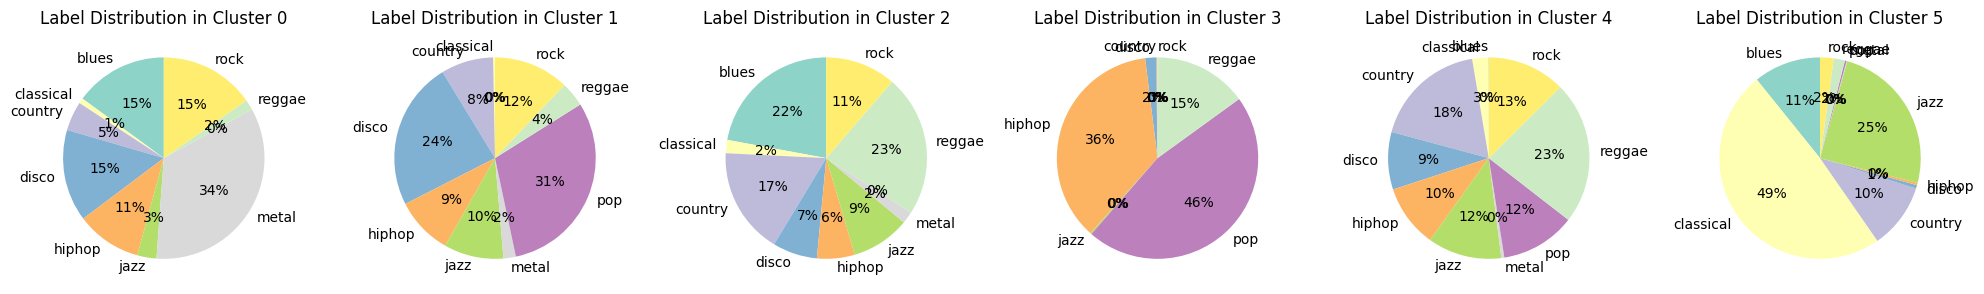

In [9]:
#Visualization 

#fit predict on training data only for the visualization purposes. 
cluster_labels = kmeans_clustering.fit_predict(X_pca)  

df["cluster"] = cluster_labels
comparison_table = pd.crosstab(df["label"], df["cluster"])
comparison_table_percentage = comparison_table.div(comparison_table.sum(axis=0), axis=1) * 100

fig, axes = plt.subplots(nrows=1, ncols=len(comparison_table_percentage.columns), figsize=(20, 10))
for i, cluster in enumerate(comparison_table_percentage.columns):
    comparison_table_percentage[cluster].plot.pie(ax=axes[i], autopct="%1.0f%%", startangle=90, cmap="Set3")
    axes[i].set_title(f"Label Distribution in Cluster {cluster}")
    axes[i].set_ylabel('')  

plt.tight_layout()
plt.show()

In [10]:
#save scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# Save models
with open('pca.pkl', 'wb') as file:
    pickle.dump(pca, file)
    
with open('kmeans.pkl', 'wb') as file:
    pickle.dump(kmeans, file)
    
print('✅Models and scaler saved successfully!')



✅Models and scaler saved successfully!


## Testing kmeans.predict on full song vs 75 sec segment 

### full song

In [11]:
#Preprocessing on new data

# Drop columns 
X_features_full_song = X_features_full_song.drop(["label", "filename", "length"], axis = 1)

# Load and apply ('transform') scaler 
my_scaler=pickle.load(open("scaler.pkl", "rb"))
X_new_scaled = my_scaler.transform(X_features_full_song)

# Load and apply ('transform')  PCA
pca = pickle.load(open('pca.pkl', 'rb'))
X_new_pca = pca.transform(X_new_scaled)

#load and predict on new data
# Load and apply ('predict') model 
kmeans = pickle.load(open('kmeans.pkl', 'rb'))
kmeans.predict(X_new_pca)

/home/tford/.pyenv/versions/3.10.6/envs/k_means_klang/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

### 75 sec snippet

In [12]:
#Preprocessing on new data

# Drop columns 
X_features_snippet = X_features_snippet.drop(["label", "filename", "length"], axis = 1)

# Load and apply ('transform') scaler 
my_scaler=pickle.load(open("scaler.pkl", "rb"))
X_new_scaled = my_scaler.transform(X_features_snippet)

# Load and apply ('transform')  PCA
pca = pickle.load(open('pca.pkl', 'rb'))
X_new_pca = pca.transform(X_new_scaled)

#load and predict on new data
# Load and apply ('predict') model 
kmeans = pickle.load(open('kmeans.pkl', 'rb'))
kmeans.predict(X_new_pca)

/home/tford/.pyenv/versions/3.10.6/envs/k_means_klang/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


array([2], dtype=int32)